In [1]:
pip install lightgbm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier,GradientBoostingClassifier
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

### Data Collection

In [3]:
client_credit_card_data = pd.read_csv(r"credit_card_clean.csv")

### Data Understanding

In [4]:
client_credit_card_data

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,1,20000.0,female,university,married,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,female,university,single,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,female,university,single,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,female,university,married,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,male,university,married,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000.0,male,highschool,married,39,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,29997,150000.0,male,highschool,single,43,-1,-1,-1,-1,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,29998,30000.0,male,university,single,37,4,3,2,-1,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,29999,80000.0,male,highschool,married,41,1,-1,0,0,...,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1


In [5]:
client_credit_card_data.shape

(30000, 25)

In [6]:
client_credit_card_data.isna().sum()

ID           0
LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_1        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
DEFAULT      0
dtype: int64

In [7]:
client_credit_card_data.describe(include="all")

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
count,30000.000000,30000.000000,30000,30000,30000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
unique,NaN,NaN,2,4,3,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,female,university,single,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,18112,14030,15964,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,15000.500000,167484.322667,NaN,NaN,NaN,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,NaN,NaN,NaN,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,NaN,NaN,NaN,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,NaN,NaN,NaN,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,NaN,NaN,NaN,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,NaN,NaN,NaN,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000


In [8]:
client_credit_card_data.dtypes

ID             int64
LIMIT_BAL    float64
SEX           object
EDUCATION     object
MARRIAGE      object
AGE            int64
PAY_1          int64
PAY_2          int64
PAY_3          int64
PAY_4          int64
PAY_5          int64
PAY_6          int64
BILL_AMT1    float64
BILL_AMT2    float64
BILL_AMT3    float64
BILL_AMT4    float64
BILL_AMT5    float64
BILL_AMT6    float64
PAY_AMT1     float64
PAY_AMT2     float64
PAY_AMT3     float64
PAY_AMT4     float64
PAY_AMT5     float64
PAY_AMT6     float64
DEFAULT        int64
dtype: object

In [9]:
print(client_credit_card_data["SEX"].value_counts())
print(client_credit_card_data["EDUCATION"].value_counts())
print(client_credit_card_data["MARRIAGE"].value_counts())

SEX
female    18112
male      11888
Name: count, dtype: int64
EDUCATION
university    14030
grad          10585
highschool     4917
other           468
Name: count, dtype: int64
MARRIAGE
single     15964
married    13659
other        377
Name: count, dtype: int64


### Data Preparation

In [10]:
labelencoder = LabelEncoder()
client_credit_card_data["SEX"] = labelencoder.fit_transform(client_credit_card_data["SEX"])
client_credit_card_data["EDUCATION"] = labelencoder.fit_transform(client_credit_card_data["EDUCATION"])
client_credit_card_data["MARRIAGE"] = labelencoder.fit_transform(client_credit_card_data["MARRIAGE"])

In [11]:
del client_credit_card_data["ID"]

In [12]:
client_credit_card_data

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,20000.0,0,3,0,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,0,3,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,0,3,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,0,3,0,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,1,3,0,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000.0,1,1,0,39,0,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,150000.0,1,1,2,43,-1,-1,-1,-1,0,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,30000.0,1,3,2,37,4,3,2,-1,0,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,80000.0,1,1,0,41,1,-1,0,0,0,...,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1


### Model Building

In [13]:
X = client_credit_card_data.drop("DEFAULT",axis=1)
y = client_credit_card_data["DEFAULT"]

In [14]:
print(X)
print(y)

       LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_1  PAY_2  PAY_3  PAY_4  \
0        20000.0    0          3         0   24      2      2     -1     -1   
1       120000.0    0          3         2   26     -1      2      0      0   
2        90000.0    0          3         2   34      0      0      0      0   
3        50000.0    0          3         0   37      0      0      0      0   
4        50000.0    1          3         0   57     -1      0     -1      0   
...          ...  ...        ...       ...  ...    ...    ...    ...    ...   
29995   220000.0    1          1         0   39      0      0      0      0   
29996   150000.0    1          1         2   43     -1     -1     -1     -1   
29997    30000.0    1          3         2   37      4      3      2     -1   
29998    80000.0    1          1         0   41      1     -1      0      0   
29999    50000.0    1          3         0   46      0      0      0      0   

       PAY_5  ...  BILL_AMT3  BILL_AMT4  BILL_AMT5 

In [15]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=9,shuffle=True,stratify=y)

In [16]:
agb_classifier = AdaBoostClassifier()
gb_classifier = GradientBoostingClassifier()
xgbm_classifier = XGBClassifier()
lgbm_classifier = LGBMClassifier()

### Model Training

In [17]:
models = [agb_classifier,gb_classifier,xgbm_classifier,lgbm_classifier]
#for i in models:
#    i.fit(X_train,y_train)

In [18]:
%%time
models[0].fit(X_train,y_train)

CPU times: total: 2.86 s
Wall time: 2.85 s


,estimator,None
,n_estimators,50
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,None


In [19]:
%%time
models[1].fit(X_train,y_train)

CPU times: total: 13.6 s
Wall time: 13.7 s


,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [20]:
%%time
models[2].fit(X_train,y_train)

CPU times: total: 1.7 s
Wall time: 1.15 s


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [21]:
%%time
models[3].fit(X_train,y_train)

[LightGBM] [Info] Number of positive: 5309, number of negative: 18691
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001597 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3260
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.221208 -> initscore=-1.258639
[LightGBM] [Info] Start training from score -1.258639
CPU times: total: 1.5 s
Wall time: 4.32 s


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


### Model Testing

In [22]:
predictions = []
for i in models:
    predictions.append(i.predict(X_test))
predictions

[array([1, 0, 1, ..., 0, 0, 0], shape=(6000,)),
 array([1, 0, 1, ..., 0, 0, 0], shape=(6000,)),
 array([1, 0, 1, ..., 0, 0, 0], shape=(6000,)),
 array([1, 0, 1, ..., 0, 0, 0], shape=(6000,))]

### Model Evaluation

In [23]:
for model,y_pred in zip(models,predictions):
    print("Evaluation of ",model.__class__.__name__)
    print("Accuracy Score: ",round(accuracy_score(y_test,y_pred),2))
    print("Precison Score: ",round(precision_score(y_test,y_pred),2))
    print("Recall Score: ",round(recall_score(y_test,y_pred),2))
    print("Confusion Matrix: \n",confusion_matrix(y_test,y_pred))

Evaluation of  AdaBoostClassifier
Accuracy Score:  0.82
Precison Score:  0.68
Recall Score:  0.34
Confusion Matrix: 
 [[4460  213]
 [ 873  454]]
Evaluation of  GradientBoostingClassifier
Accuracy Score:  0.82
Precison Score:  0.67
Recall Score:  0.37
Confusion Matrix: 
 [[4437  236]
 [ 838  489]]
Evaluation of  XGBClassifier
Accuracy Score:  0.81
Precison Score:  0.63
Recall Score:  0.36
Confusion Matrix: 
 [[4397  276]
 [ 851  476]]
Evaluation of  LGBMClassifier
Accuracy Score:  0.82
Precison Score:  0.66
Recall Score:  0.37
Confusion Matrix: 
 [[4425  248]
 [ 841  486]]


### Featuren Importance

In [24]:
agbc = agb_classifier.feature_importances_
gbc = gb_classifier.feature_importances_
xgbmc = xgbm_classifier.feature_importances_
lgbmc = lgbm_classifier.feature_importances_

In [25]:
Feature_scores_DataFrame = pd.DataFrame({"Feature Names":X.columns,"AdaBoostClassifier":agbc,"GradientBoostingClassifier":gbc,"XGBClassifier":xgbmc,"LGBMClassifier":lgbmc})

In [26]:
Feature_scores_DataFrame

,Feature Names,AdaBoostClassifier,GradientBoostingClassifier,XGBClassifier,LGBMClassifier
0,LIMIT_BAL,0.041399,0.026953,0.023017,260
1,SEX,0.015014,0.002249,0.022029,37
2,EDUCATION,0.000000,0.003893,0.018525,64
3,MARRIAGE,0.000000,0.003265,0.014952,27
4,AGE,0.016006,0.010023,0.019425,211
5,PAY_1,0.479005,0.636214,0.385136,84
6,PAY_2,0.021232,0.086667,0.102952,40
7,PAY_3,0.051069,0.024290,0.042096,47
8,PAY_4,0.000000,0.015128,0.044357,38
9,PAY_5,0.011453,0.020530,0.045570,37


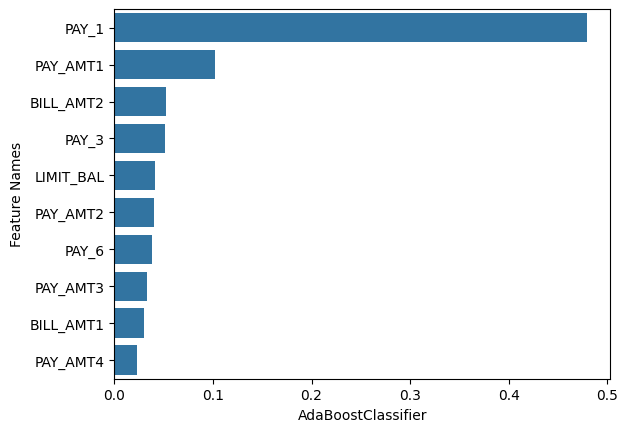

In [27]:
Ada_boost_features = Feature_scores_DataFrame.sort_values(by="AdaBoostClassifier",ascending=False).head(10)
sns.barplot(data = Ada_boost_features,x="AdaBoostClassifier",y="Feature Names")
plt.show()

In [48]:
Ada_boost_features["Feature Names"].tolist()

['PAY_1',
 'PAY_AMT1',
 'BILL_AMT2',
 'PAY_3',
 'LIMIT_BAL',
 'PAY_AMT2',
 'PAY_6',
 'PAY_AMT3',
 'BILL_AMT1',
 'PAY_AMT4']

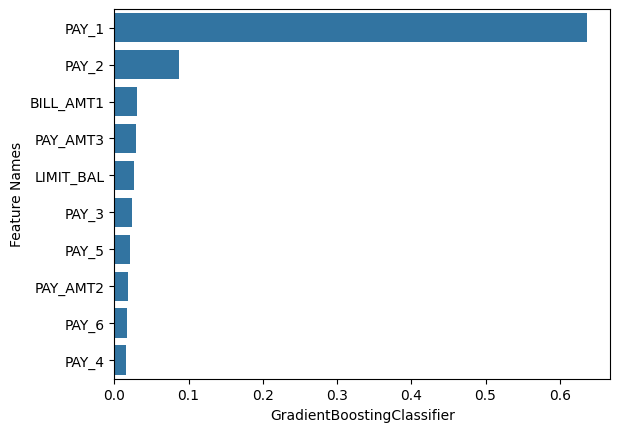

In [28]:
GB_features = Feature_scores_DataFrame.sort_values(by="GradientBoostingClassifier",ascending=False).head(10)
sns.barplot(data = GB_features,x="GradientBoostingClassifier",y="Feature Names")
plt.show()

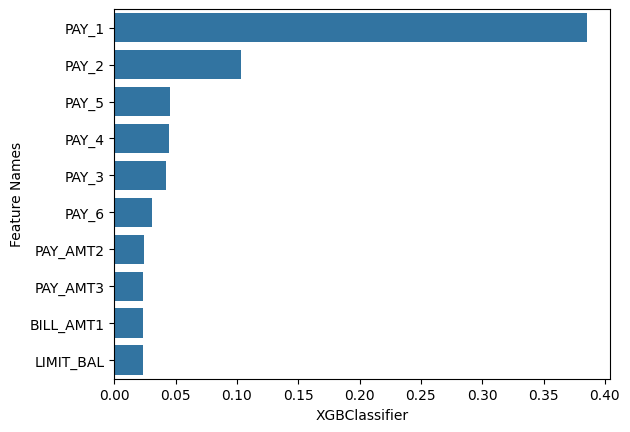

In [29]:
XGB_features = Feature_scores_DataFrame.sort_values(by="XGBClassifier",ascending=False).head(10)
sns.barplot(data = XGB_features,x="XGBClassifier",y="Feature Names")
plt.show()

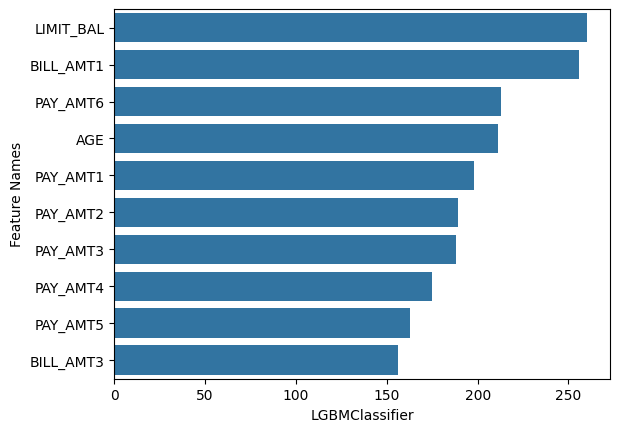

In [30]:
LGBM_features = Feature_scores_DataFrame.sort_values(by="LGBMClassifier",ascending=False).head(10)
sns.barplot(data = LGBM_features,x="LGBMClassifier",y="Feature Names")
plt.show()

#### Using selected features for building an ada boost

In [53]:
ADABOOST_dataframe = client_credit_card_data[['PAY_1',
 'PAY_AMT1',
 'BILL_AMT2',
 'PAY_3',
 'LIMIT_BAL',
 'PAY_AMT2',
 'PAY_6',
 'PAY_AMT3',
 'BILL_AMT1',
 'PAY_AMT4',"DEFAULT"]] 

In [54]:
ADABOOST_dataframe

,PAY_1,PAY_AMT1,BILL_AMT2,PAY_3,LIMIT_BAL,PAY_AMT2,PAY_6,PAY_AMT3,BILL_AMT1,PAY_AMT4,DEFAULT
0,2,0.0,3102.0,-1,20000.0,689.0,-2,0.0,3913.0,0.0,1
1,-1,0.0,1725.0,0,120000.0,1000.0,2,1000.0,2682.0,1000.0,1
2,0,1518.0,14027.0,0,90000.0,1500.0,0,1000.0,29239.0,1000.0,0
3,0,2000.0,48233.0,0,50000.0,2019.0,0,1200.0,46990.0,1100.0,0
4,-1,2000.0,5670.0,-1,50000.0,36681.0,0,10000.0,8617.0,9000.0,0
...,...,...,...,...,...,...,...,...,...,...,...
29995,0,8500.0,192815.0,0,220000.0,20000.0,0,5003.0,188948.0,3047.0,0
29996,-1,1837.0,1828.0,-1,150000.0,3526.0,0,8998.0,1683.0,129.0,0
29997,4,0.0,3356.0,2,30000.0,0.0,0,22000.0,3565.0,4200.0,1
29998,1,85900.0,78379.0,0,80000.0,3409.0,-1,1178.0,-1645.0,1926.0,1


In [55]:
ADA_X = ADABOOST_dataframe.drop("DEFAULT",axis = 1)
ADA_Y = ADABOOST_dataframe["DEFAULT"]

In [57]:
ADA_X_train,ADA_X_test,ADA_y_train,ADA_y_test = train_test_split(ADA_X,ADA_Y,test_size=0.2,shuffle=True,random_state=9,stratify=ADA_Y)

In [58]:
ada_classifier_1 = AdaBoostClassifier()

In [59]:
ada_classifier_1.fit(ADA_X_train,ADA_y_train)

,estimator,None
,n_estimators,50
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,None


In [61]:
ADA_Y_pred = ada_classifier_1.predict(ADA_X_test)

In [62]:
print("Accuracy: \n",accuracy_score(ADA_y_test,ADA_Y_pred))
print("Precison Score: ",round(precision_score(ADA_y_test,ADA_Y_pred),2))
print("Recall Score: ",round(recall_score(ADA_y_test,ADA_Y_pred),2))
print("Confusion Matrix: \n",confusion_matrix(ADA_y_test,ADA_Y_pred))

Accuracy: 
 0.8186666666666667
Precison Score:  0.68
Recall Score:  0.34
Confusion Matrix: 
 [[4457  216]
 [ 872  455]]
